# Import library

In [654]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Loading the dataset

In [655]:
df = pd.read_csv('store_customers.csv')

# Display Basic Infomation

- Dataset overview

In [656]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [657]:
df.shape

(1000, 5)

In [658]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [659]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

Dataset bao gồm 1000 dòng và 5 cột:
+ CustumerID: Là cột kiểu số nguyên chứa ID khách hàng. Không có giá trị bị thiếu
+ Gender: Là cột kiểu string chứa giới tính khách hàng. Thiếu 3 giá trị
+ Age: là cột kiểu số thực chứa tuổi của khách hàng. Thiếu 6 giá trị
+ Annual income: là cột kiểu số thực chứa thu thập cá nhân của từng khách hàng. Thiếu 4 giá trị
+ Spending score: là cột kiểu số thực chứa điểm chi tiêu mua hàng của từng cá nhân. Thiếu 6 giá trị 

- SUMMARY STATISTIC

In [660]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,1000.0,1499.500000,288.819436,1000.0,1249.750,1499.5,1749.25,1999.0
Age,994.0,38.935614,13.399880,18.0,30.000,36.0,44.00,80.0
Annual Income (k$),996.0,57.149096,28.628506,15.0,34.975,49.0,79.40,144.1
Spending Score (1-100),994.0,42.645875,20.101589,1.0,31.000,47.0,57.00,92.0


In [661]:
df.describe(include='object').T

C:\Users\dotra\AppData\Local\Temp\ipykernel_13912\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Gender,997,2,F,522


# Data Preprocessing

- Fix Gender

In [662]:
# Encode categorical variables (Gender)
# 0 = Female, 1 = Male
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

- Handling missing values

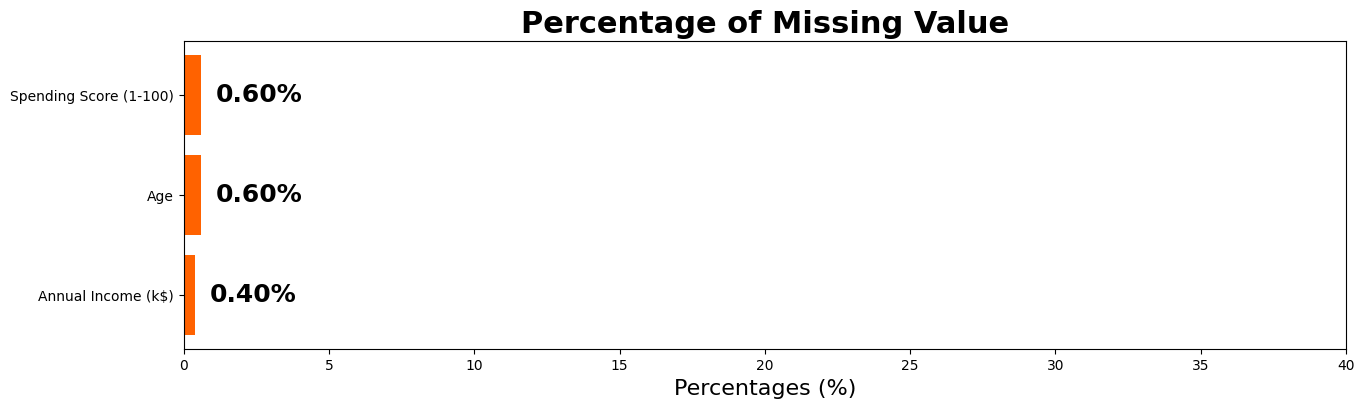

In [663]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

missing_percentage.sort_values(ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

ax.set_xlim([0, 40])

plt.title("Percentage of Missing Value", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

Dữ liệu cho thấy các biến số bao gồm spending score, age, annual income và biến phân loại gồm gender đều có tỷ lệ thiếu hụt rất thấp dao động khoảng 0.3%-0.6%. Tổng số giá trị bị thiếu không ảnh hưởng gì nhiều tới dữ liệu mẫu. Do đó, việc xóa các hàng bị thiếu là cách tiếp cận hợp lý để duy trì tính toàn vẹnh của các cụm.

In [664]:
df[df['Age'].isnull() | df['Gender'].isnull() | df['Annual Income (k$)'].isnull() | df['Spending Score (1-100)'].isnull()].head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
26,1026,1,NaN,21.2,50.0
67,1067,0,NaN,79.1,41.0
105,1105,0,38.0,38.1,NaN
117,1117,1,26.0,22.7,NaN
134,1134,0,NaN,38.5,50.0


In [665]:
if df.isnull().sum().sum() > 0:

    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])


In [666]:
# Verifying the removal of missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [667]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  1000 non-null   int64  
 2   Age                     1000 non-null   float64
 3   Annual Income (k$)      1000 non-null   float64
 4   Spending Score (1-100)  1000 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 39.2 KB


- Handling duplicates

In [668]:
# find rows duplicated
duplicate_rows = df[df.duplicated(keep=False)]
# Sort data with columns
duplicate_rows_sorted = duplicate_rows.sort_values(by=['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
duplicate_rows_sorted.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [669]:
# Reduce value outlier
feature_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in feature_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [670]:
# Scaling feature
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Dataset (first 5 rows):")
print(X_scaled)


Scaled Dataset (first 5 rows):
[[ 0.00698096  0.09897992  0.76899451]
 [-0.36833947 -0.30494952 -0.28243362]
 [ 0.08204505  0.4712975  -0.83318169]
 ...
 [ 0.53242956  0.37294946 -0.83318169]
 [-0.81872399 -0.39978513  0.81906251]
 [ 2.10877537  1.78143387 -2.08488184]]


# EDA

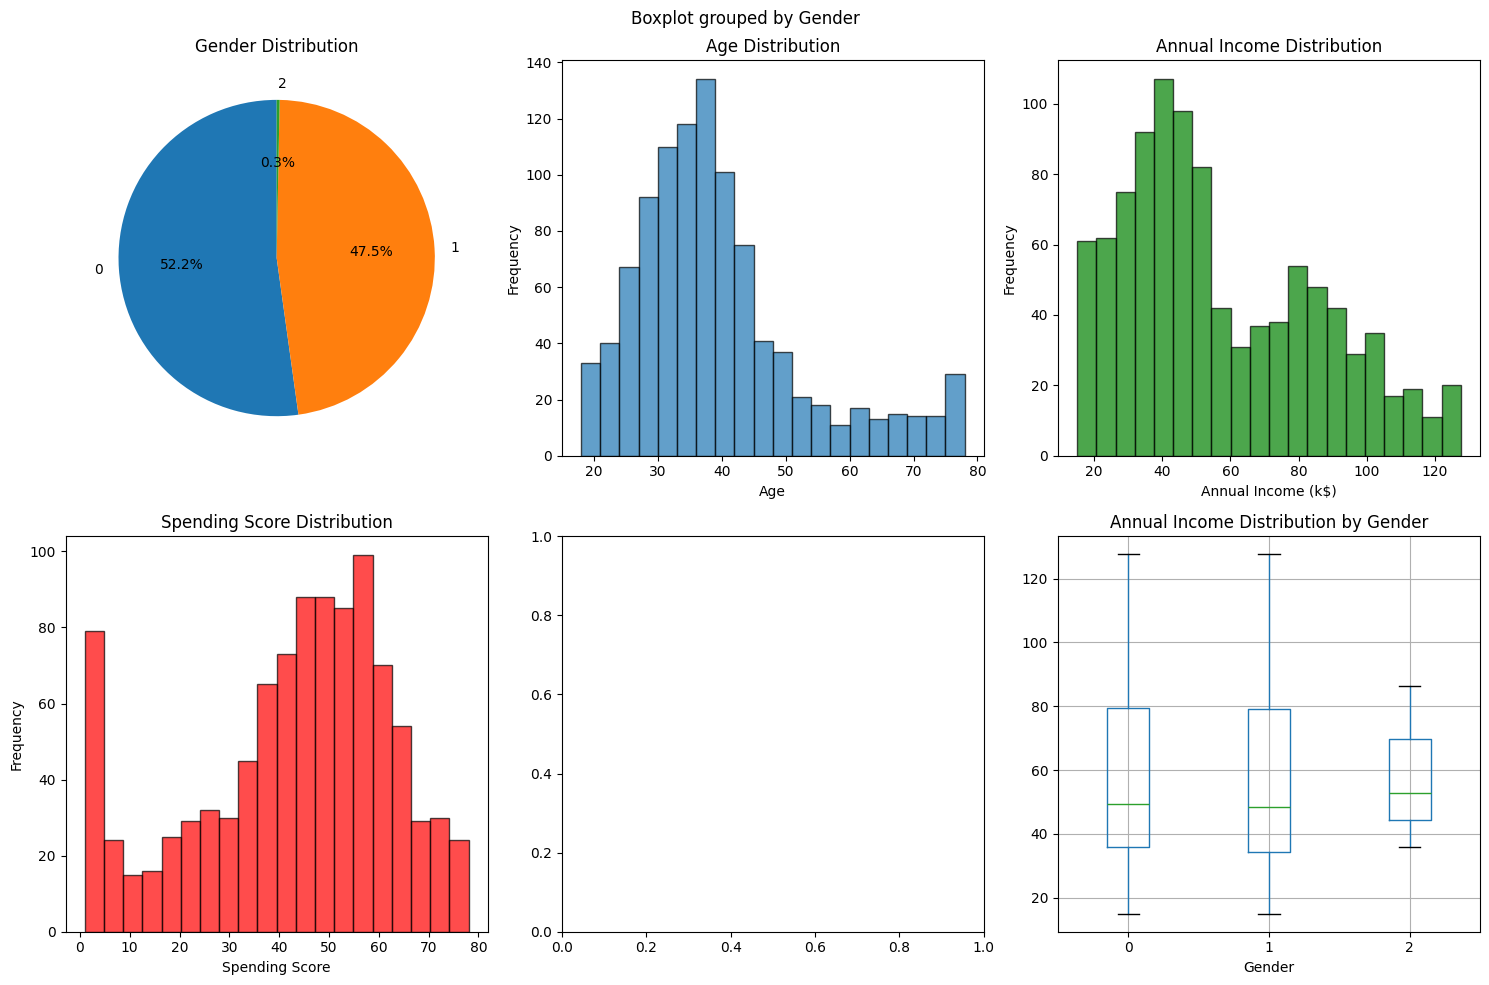

In [671]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution of Gender
gender_counts = df['Gender'].value_counts()
axes[0, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Gender Distribution')

# Distribution of Age
axes[0, 1].hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# Distribution of Annual Income
axes[0, 2].hist(df['Annual Income (k$)'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('Annual Income Distribution')
axes[0, 2].set_xlabel('Annual Income (k$)')
axes[0, 2].set_ylabel('Frequency')

# Distribution of Spending Score
axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Spending Score')
axes[1, 0].set_ylabel('Frequency')

# Box plot for Annual Income by Gender
df.boxplot(column='Annual Income (k$)', by='Gender', ax=axes[1, 2])
axes[1, 2].set_title('Annual Income Distribution by Gender')
axes[1, 2].set_xlabel('Gender')

plt.tight_layout()
plt.show()

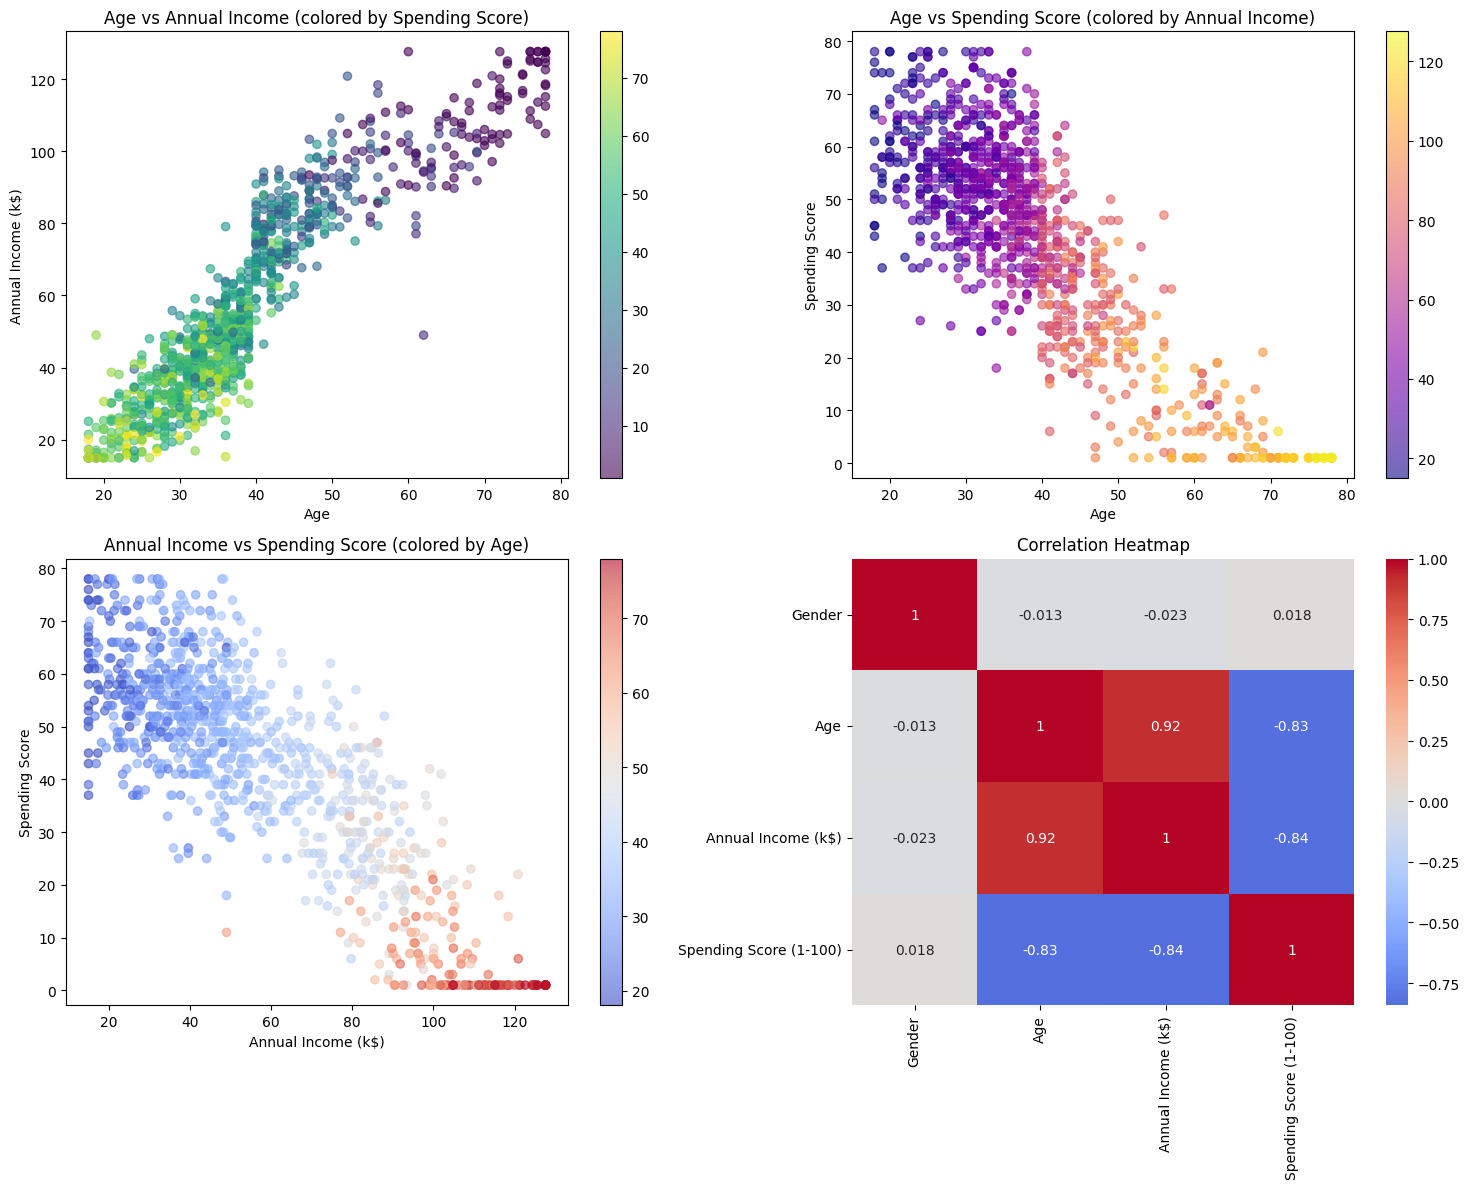

In [672]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot: Age vs Annual Income
scatter1 = axes[0, 0].scatter(df['Age'], df['Annual Income (k$)'], 
                              c=df['Spending Score (1-100)'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Annual Income (k$)')
axes[0, 0].set_title('Age vs Annual Income (colored by Spending Score)')
plt.colorbar(scatter1, ax=axes[0, 0])

# Scatter plot: Age vs Spending Score
scatter2 = axes[0, 1].scatter(df['Age'], df['Spending Score (1-100)'], 
                              c=df['Annual Income (k$)'], cmap='plasma', alpha=0.6)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Spending Score')
axes[0, 1].set_title('Age vs Spending Score (colored by Annual Income)')
plt.colorbar(scatter2, ax=axes[0, 1])

# Scatter plot: Annual Income vs Spending Score
scatter3 = axes[1, 0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                              c=df['Age'], cmap='coolwarm', alpha=0.6)
axes[1, 0].set_xlabel('Annual Income (k$)')
axes[1, 0].set_ylabel('Spending Score')
axes[1, 0].set_title('Annual Income vs Spending Score (colored by Age)')
plt.colorbar(scatter3, ax=axes[1, 0])

# Correlation heatmap
correlation_matrix = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

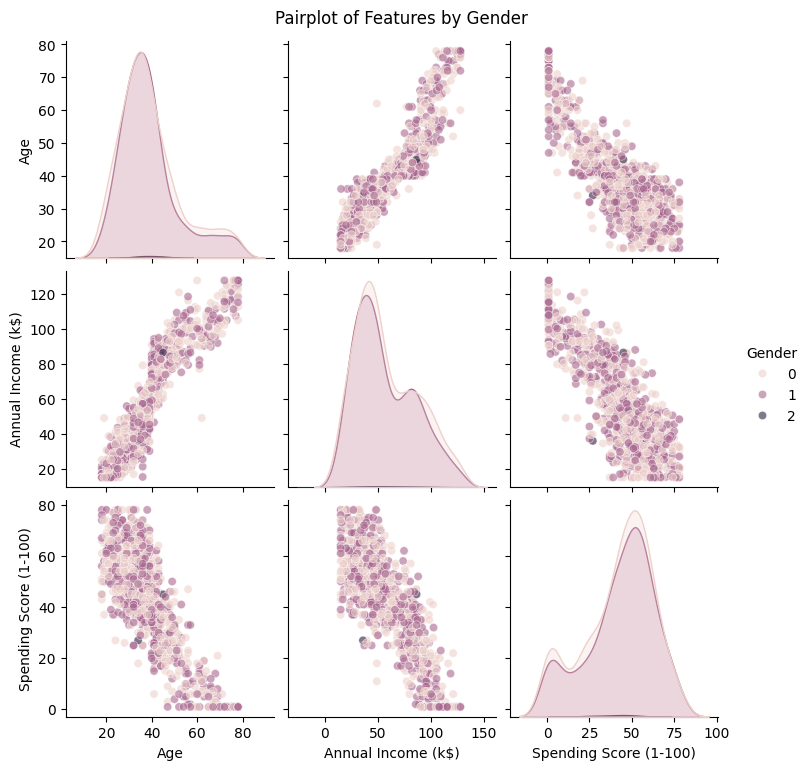

In [673]:
# Create a pairplot with hue based on Gender (original categorical)
df_viz = df.copy()
sns.pairplot(df_viz, hue='Gender', vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Features by Gender', y=1.02)
plt.show()

# Model

In [674]:
class KMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=None):
        self.k=k
        self.max_iters=max_iters
        self.tol=tol
        self.random_state=random_state
        self.inertia_per_iteration = [] #store inertia history

    def fit(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        #Step 1: Initialize centroid randomly
        random_indices = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            # Step 2: Assign points to closest centroid
            labels = self._assign_clusters(X)

            # Step 3: Compute new centroid
            new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(self.k)])

            # Step 4: Compute inertia (SSE)
            inertia = np.sum((X - self.centroids[labels]) ** 2)
            self.inertia_per_iteration.append(inertia)

            # Step 5: Check for convergence (centroid shift < tol)
            if np.all(np.linalg.norm(new_centroids - self.centroids, axis=1) < self.tol):
                break
            self.centroids = new_centroids
        
        self.labels = self._assign_clusters(X)
        self.inertia = self.inertia_per_iteration[-1]
    def _assign_clusters(self, X):
        # Compute distance from point to centroid
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        # return nearest index centroid
        return np.argmin(distances, axis=1)
    
    def predict(self, X):
        return self._assign_clusters(X)
    
# Visualizing K-means
def plot_clusters_for_k(X, ks=[2, 3, 4, 5]):
    fig, axes = plt.subplots(1, len(ks), figsize=(4 * len(ks), 4))

    for idx, k in enumerate(ks):
        # Use class K-means before
        kmeans = KMeans(k=k, max_iters=100, random_state=42)
        kmeans.fit(X)

        # draw points with color scatter
        axes[idx].scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis', s=30)
        
        # draw centroid with X color red
        axes[idx].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
                          c='red', marker='X', s=200, label="Centroids")
        
        axes[idx].set_title(f"k = {k}")
        axes[idx].legend()
        
    plt.tight_layout()
    plt.show()

# Train Model

In [675]:
def silhouette_score_custom(X, labels):
    # function cumpute silhouette
    n = len(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2: return 0
    
    scores = []
    for i in range(n):
        # a: Khoảng cách trung bình nội cụm
        same_cluster = X[labels == labels[i]]
        a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1)) if len(same_cluster) > 1 else 0
        
        # b: Khoảng cách trung bình đến cụm gần nhất khác
        b = min([np.mean(np.linalg.norm(X[labels == l] - X[i], axis=1)) 
                 for l in unique_labels if l != labels[i]])
        
        s = (b - a) / max(a, b) if max(a, b) > 0 else 0
        scores.append(s)
    return np.mean(scores)

def elbow_and_silhouette(X, max_k=10):
    inertias = []
    silhouette_scores = []
    Ks = range(2, max_k + 1)

    for k in Ks:
        kmeans = KMeans(k=k, max_iters=100, random_state=42)
        kmeans.fit(X)
        
        # Lưu Inertia (SSE)
        inertias.append(kmeans.inertia_per_iteration[-1])
        
        # Lưu Silhouette Score
        score = silhouette_score_custom(X, kmeans.labels)
        silhouette_scores.append(score)

    # Vẽ biểu đồ so sánh
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Biểu đồ Elbow
    axes[0].plot(Ks, inertias, marker='o', color='blue')
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("Inertia (SSE)")

    # Biểu đồ Silhouette
    axes[1].plot(Ks, silhouette_scores, marker='o', color='green')
    axes[1].set_title("Silhouette Analysis")
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")

    # Mark the best silhouette score
    best_k = Ks[np.argmax(silhouette_scores)]
    axes[1].axvline(x=best_k, color='green', linestyle='--', 
                label=f'Best k={best_k} (score={max(silhouette_scores):.3f})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print(f"Optimal number of clusters based on silhouette score: {best_k}")
    
    return inertias, silhouette_scores

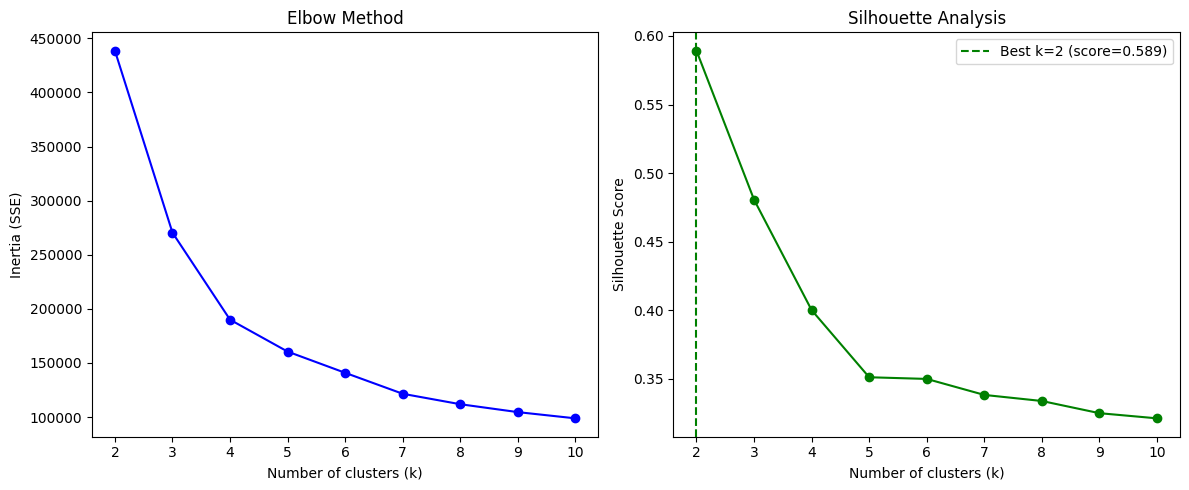

Optimal number of clusters based on silhouette score: 2


In [676]:
inertias, sil_score = elbow_and_silhouette(X, max_k=10)

Cluster Distribution:
Cluster
0    184
1    126
2    232
3    232
4    226
Name: count, dtype: int64


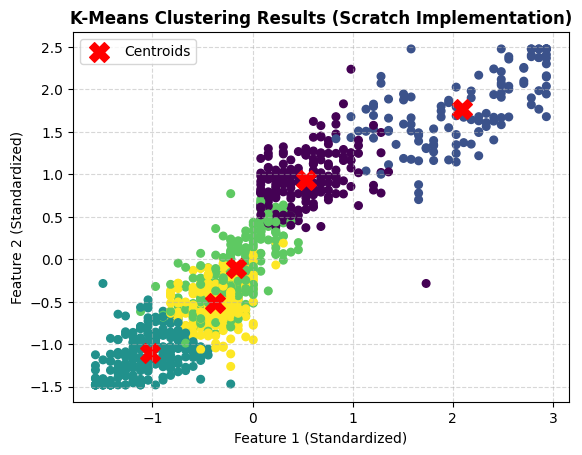

In [677]:
# Based on the elbow method, let's use k=5
kmeans = KMeans(k=5, max_iters=100, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels

# Add cluster labels to the original dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = cluster_labels

print("Cluster Distribution:")
print(df_with_clusters['Cluster'].value_counts().sort_index())

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels, cmap='viridis', s=30)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering Results (Scratch Implementation)", fontweight='bold')
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

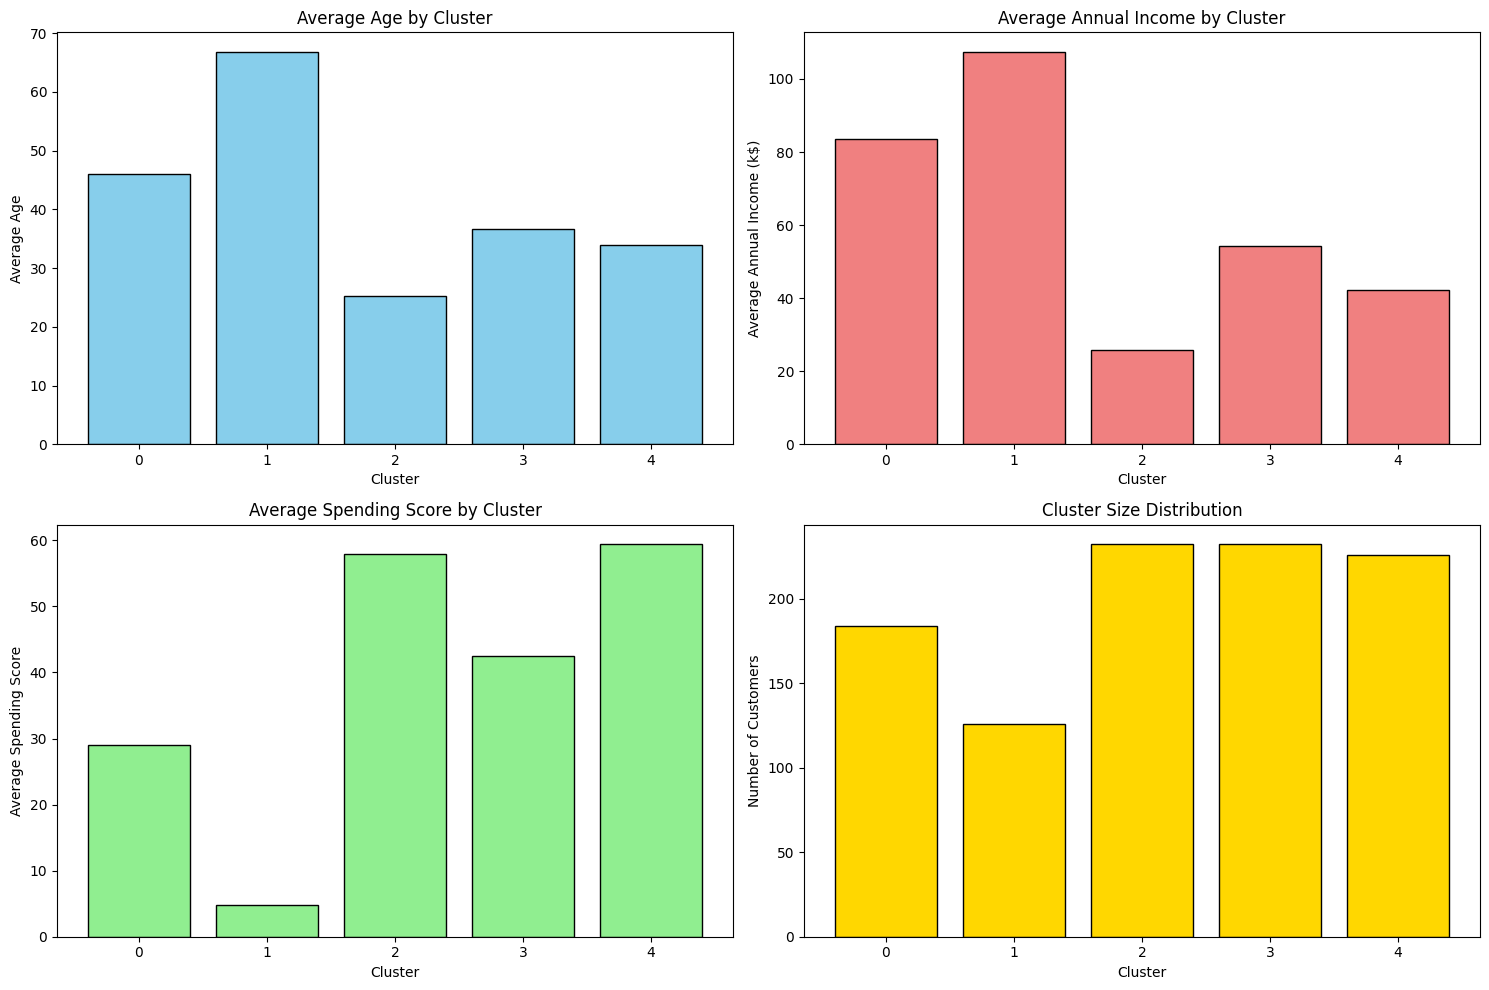

In [678]:
# Calculate cluster statistics
cluster_stats = df_with_clusters.groupby('Cluster').agg({
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)

cluster_stats['Size'] = df_with_clusters['Cluster'].value_counts().sort_index().values
cluster_stats['Gender'] = cluster_stats['Gender'].map({'Male': 'M', 'Female': 'F'})

# Visualize cluster characteristics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Average Age by Cluster
axes[0, 0].bar(cluster_stats.index, cluster_stats['Age'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Average Age')
axes[0, 0].set_title('Average Age by Cluster')
axes[0, 0].set_xticks(cluster_stats.index)

# Average Annual Income by Cluster
axes[0, 1].bar(cluster_stats.index, cluster_stats['Annual Income (k$)'], 
               color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Annual Income (k$)')
axes[0, 1].set_title('Average Annual Income by Cluster')
axes[0, 1].set_xticks(cluster_stats.index)

# Average Spending Score by Cluster
axes[1, 0].bar(cluster_stats.index, cluster_stats['Spending Score (1-100)'], 
               color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Average Spending Score')
axes[1, 0].set_title('Average Spending Score by Cluster')
axes[1, 0].set_xticks(cluster_stats.index)

# Cluster Size
axes[1, 1].bar(cluster_stats.index, cluster_stats['Size'], 
               color='gold', edgecolor='black')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].set_title('Cluster Size Distribution')
axes[1, 1].set_xticks(cluster_stats.index)

plt.tight_layout()
plt.show()

In [679]:
print("="*60)
print("CUSTOMER SEGMENTATION ANALYSIS - CLUSTER PROFILES")
print("="*60)

cluster_profiles = {
    0: "High Income, High Spending - Premium Customers",
    1: "High Income, Low Spending - Potential Target for Upselling",
    2: "Medium Income, Medium Spending - Average Customers",
    3: "Low Income, High Spending - Careful with Marketing (May be price sensitive)",
    4: "Low Income, Low Spending - Budget Customers"
}

# Let's identify which cluster corresponds to which profile
# Sort clusters by income and spending
sorted_clusters = df_with_clusters.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
sorted_clusters['Income_Rank'] = sorted_clusters['Annual Income (k$)'].rank()
sorted_clusters['Spending_Rank'] = sorted_clusters['Spending Score (1-100)'].rank()

for cluster in range(5):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    print(f"\nCLUSTER {cluster}:")
    print(f"Size: {len(cluster_data)} customers ({len(cluster_data)/len(df_with_clusters)*100:.1f}%)")
    print(f"Gender Distribution: {cluster_data['Gender'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
    print(f"Age Range: {cluster_data['Age'].min()} - {cluster_data['Age'].max()} (Avg: {cluster_data['Age'].mean():.1f})")
    print(f"Income Range: ${cluster_data['Annual Income (k$)'].min()}k - ${cluster_data['Annual Income (k$)'].max()}k (Avg: ${cluster_data['Annual Income (k$)'].mean():.1f}k)")
    print(f"Spending Score Range: {cluster_data['Spending Score (1-100)'].min()} - {cluster_data['Spending Score (1-100)'].max()} (Avg: {cluster_data['Spending Score (1-100)'].mean():.1f})")

     # Determine profile based on income and spending
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    
    if avg_income > 70 and avg_spending > 70:
        profile = "Premium Customers (High Income, High Spending)"
    elif avg_income > 70 and avg_spending < 40:
        profile = "Potential Target for Upselling (High Income, Low Spending)"
    elif avg_income < 40 and avg_spending > 70:
        profile = "Price Sensitive High Spenders (Low Income, High Spending)"
    elif avg_income < 40 and avg_spending < 40:
        profile = "Budget Customers (Low Income, Low Spending)"
    else:
        profile = "Average Customers (Medium Income, Medium Spending)"
    
    print(f"Profile: {profile}")
    print("-" * 40)

CUSTOMER SEGMENTATION ANALYSIS - CLUSTER PROFILES

CLUSTER 0:
Size: 184 customers (18.4%)
Gender Distribution: {0: 52.2, 1: 47.3, 2: 0.5}
Age Range: 40.0 - 62.0 (Avg: 46.0)
Income Range: $49.0k - $120.8k (Avg: $83.7k)
Spending Score Range: 1.0 - 52.0 (Avg: 29.0)
Profile: Potential Target for Upselling (High Income, Low Spending)
----------------------------------------

CLUSTER 1:
Size: 126 customers (12.6%)
Gender Distribution: {0: 52.4, 1: 47.6}
Age Range: 50.0 - 78.0 (Avg: 66.8)
Income Range: $77.1k - $127.601k (Avg: $107.4k)
Spending Score Range: 1.0 - 21.0 (Avg: 4.8)
Profile: Potential Target for Upselling (High Income, Low Spending)
----------------------------------------

CLUSTER 2:
Size: 232 customers (23.2%)
Gender Distribution: {0: 50.9, 1: 49.1}
Age Range: 18.0 - 36.0 (Avg: 25.3)
Income Range: $15.0k - $49.0k (Avg: $25.8k)
Spending Score Range: 37.0 - 78.0 (Avg: 57.9)
Profile: Average Customers (Medium Income, Medium Spending)
----------------------------------------

CLUST